# **Step2_AI 강사 Agent v2.0**

## **0. 미션**

### **미션③ : 모듈 고도화1**
다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.

* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
                                   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토




### **미션④ : AI 강사 Agent 완성**
* 모듈 고도화2(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
    * 음성 변환 : 강의 목소리, 톤 조절 음성 변환
    * 영상 제작 :
        * 각 페이지 : 음성과 슬라이드 스냅샷 이미지 합성하여 영상 제작하기
        * 전체 강의 영상 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 웹 화면 연결(gradio)
    * 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 전체 Agent 그래프 구축
    * 전체를 Agent 그래프로 엮기


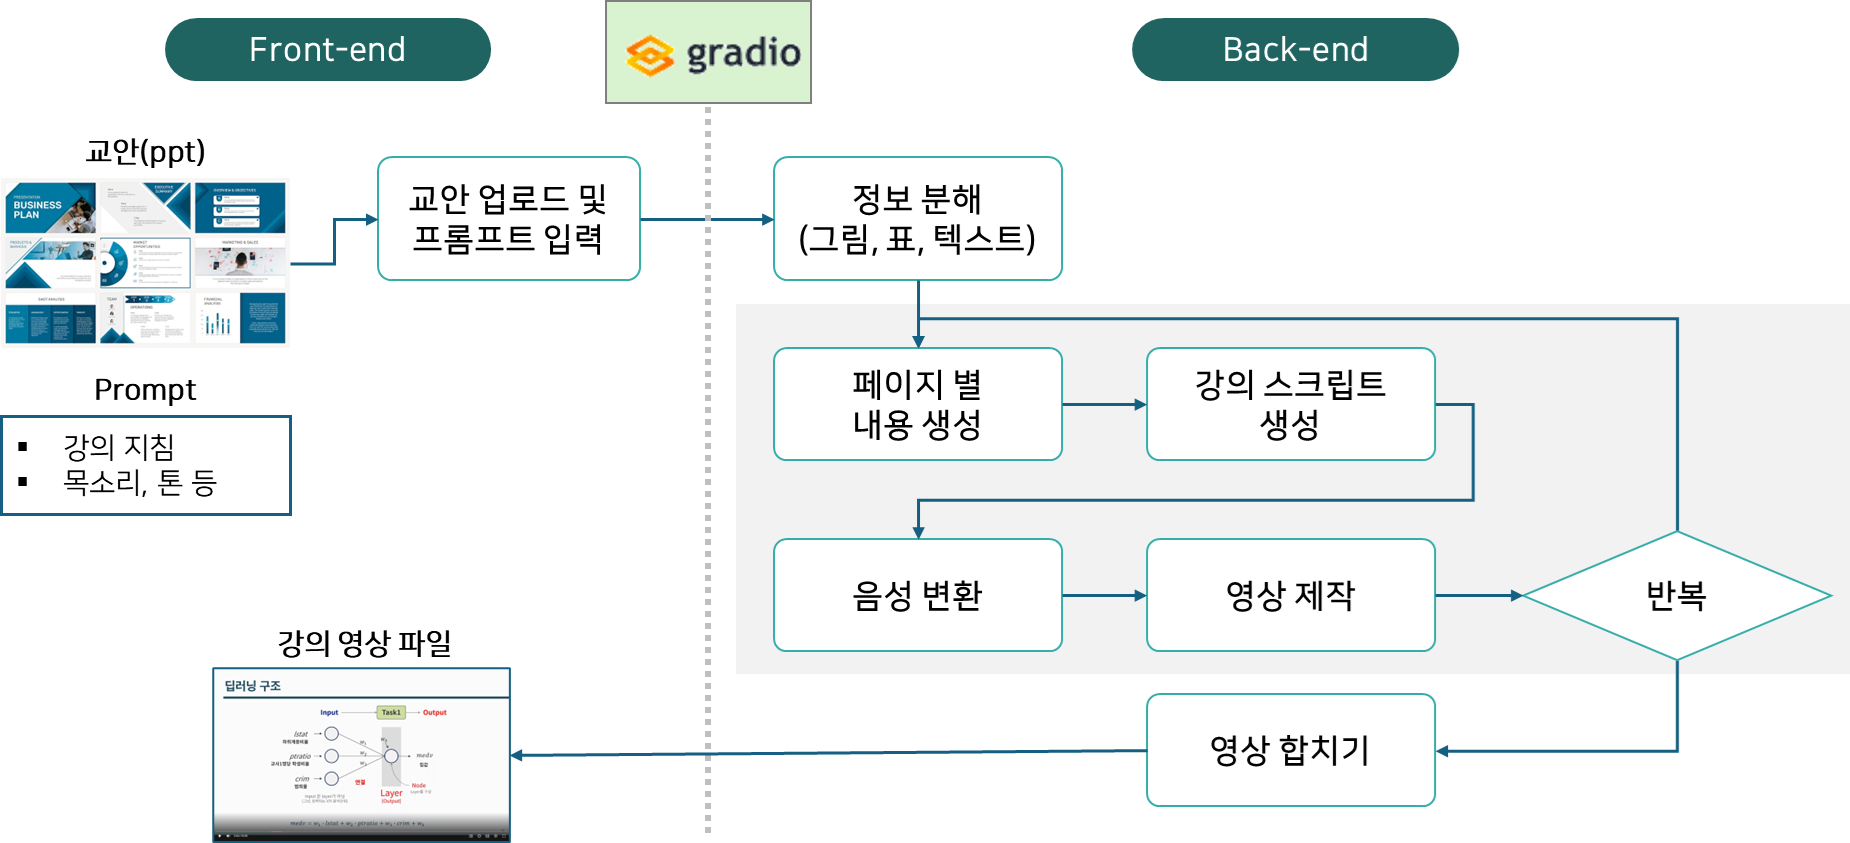

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj1_agent`를 생성하고
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 한글 폰트 준비
* 한글 폰트 설치 및 설정 코드
* 영상 제작 등 한글 사용시 필요

In [44]:
%%bash
set -e

# (1) 필수 패키지
sudo apt-get update -y
sudo apt-get install -y \
  libreoffice poppler-utils poppler-data ffmpeg locales fontconfig xvfb \
  fonts-noto-core fonts-noto-cjk fonts-noto-cjk-extra

# (2) 로케일
sudo sed -i 's/^# *ko_KR.UTF-8 UTF-8/ko_KR.UTF-8 UTF-8/' /etc/locale.gen
sudo locale-gen ko_KR.UTF-8
sudo update-locale LANG=ko_KR.UTF-8

# (3) 기존에 만들었던 사용자 fonts.conf(전체 덮어쓰기) 제거
rm -f ~/.config/fontconfig/fonts.conf || true

# (4) 시스템 fontconfig에 로컬 룰로만 추가 (기본 설정은 그대로 사용)
sudo tee /etc/fonts/local.conf >/dev/null <<'EOF'
<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>

  <!-- 한국어는 Noto Sans KR 우선 -->
  <match target="pattern">
    <test name="lang" compare="contains"><string>ko</string></test>
    <edit name="family" mode="prepend" binding="strong">
      <string>Noto Sans KR</string>
      <string>Noto Sans CJK KR</string>
      <string>Noto Sans</string>
    </edit>
  </match>

  <!-- 흔한 한글 폰트명을 Noto Sans KR로 매핑 -->
  <alias><family>Malgun Gothic</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>맑은 고딕</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>Apple SD Gothic Neo</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>AppleGothic</family><prefer><family>Noto Sans KR</family></prefer></alias>

</fontconfig>
EOF

# (5) 캐시 완전 재생성
rm -rf ~/.cache/fontconfig
sudo fc-cache -r
fc-cache -f -v >/dev/null

# (6) 검증
echo "---- fc-match ko ----"
fc-match "sans-serif:lang=ko"
echo "---- noto candidates ----"
fc-list | grep -i -E "noto.*(sans|cjk).*kr" | head -n 30 || true

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
fontconfig is already the newest version (2.13.1-4.2ubuntu5).
fonts-noto-cjk is already the newest version (1:20220127+repack1

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


### (3) 라이브러리

* 필요한 라이브러리 설치

In [45]:
!pip install langchain-openai langchain-community python-pptx pillow gradio langchain-tavily tavily-python -q

* 라이브러리 로딩

In [46]:
import os, re, textwrap, subprocess, json, base64, mimetypes, shlex
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Optional, TypedDict, Any
from PIL import Image, ImageDraw
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE
from openai import OpenAI
from google.colab import files
from IPython.display import Audio, display, Video
from typing import Literal

from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import END

### (4) API Key 확인
* 구글드라이브에 생성한 폴더 `proj1_agent` 에서
* api_key.txt 파일 안에 각자 발급 받은 키를 저장합니다.
    * **OPENAI_API_KEY**
    * **TAVILY_API_KEY**

In [47]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/proj1_agent/'
# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [48]:
print(os.environ['OPENAI_API_KEY'][:30])
print(os.environ['TAVILY_API_KEY'][:30])

sk-proj-debU9kkM8Y_Jk1qW-9z9GP
tvly-dev-3Gx1f-XbGpHl86VsZFnKQ


### (5) 유용한 함수들 제공
* 다음은 프로젝트를 수행하는데 유용한 함수들입니다.
* 이 함수들의 내용을 확인하고 필요시 활용하여 개인 과제를 수행합니다.(꼭 활용해야 하는 것은 아닙니다.)

* 공백 제거 함수

In [49]:
def clean_text(s):
    return re.sub(r"\s+", " ", s).strip()

* 긴 문자열을 문장 단위로 나누는 문장 분리기

In [50]:
def split_sents(t: str) -> List[str]:
    parts = re.split(r'([\.?!])', t)
    merged = []
    for i in range(0, len(parts)-1, 2):
        sent = (parts[i] + parts[i+1]).strip()
        if sent: merged.append(sent)
    if len(parts) % 2 == 1 and parts[-1].strip():
        merged.append(parts[-1].strip())
    return [s for s in merged if s]

* 오디오 길이 계산

In [51]:
def ffprobe_duration(path: str) -> float:
    out = subprocess.check_output([
        "ffprobe","-v","error","-show_entries","format=duration",
        "-of","default=noprint_wrappers=1:nokey=1", path]).decode().strip()
    return float(out)

* 이미지를 base64로 변환

In [52]:
def img_to_data_url(path: str) -> str:
    mime = mimetypes.guess_type(path)[0] or "image/png"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

* 배경 이미지와 오디오 합쳐서 MP4 영상 만들기

In [53]:
def render_mp4(image_path: str, audio_path: str, out_mp4: str,
               width=1920, height=1080, ):

    dur = ffprobe_duration(audio_path)

    vf = (f"scale={width}:{height}:force_original_aspect_ratio=decrease,"
          f"pad={width}:{height}:(ow-iw)/2:(oh-ih)/2:color=black"  )

    # FFmpeg 명령
    cmd = ["ffmpeg", "-y",
            "-loop", "1", "-i", image_path,   # 정지 이미지 입력
            "-i", audio_path,                 # 오디오 입력
            "-t", str(dur),                   # 길이 = 오디오 길이
            "-vf", vf,                        # 비디오 필터
            "-c:v", "libx264", "-preset", "veryfast", "-crf", "20",
            "-c:a", "aac", "-b:a", "192k",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",        # 웹/브라우저 재생 친화
            out_mp4]
    subprocess.check_call(cmd)  # 외부 프로그램(FFmpeg)을 파이썬 프로세스에서 실행하고, 성공했는지 확인

* ppt 슬라이드를 배경 이미지로 저장
    * 강의 영상에서 사용할 배경 이미지 생성하기
    * ppt를 pdf로 변환한 뒤 다시 이미지로 변환

In [54]:
import os, subprocess, uuid
from pathlib import Path

def export_slide_as_png(state: dict, dpi: int = 220) -> dict:
    work_dir = Path(state["work_dir"]).expanduser().resolve()
    work_dir.mkdir(parents=True, exist_ok=True)

    pptx = Path(state["pptx_path"]).expanduser().resolve()
    if not pptx.exists():
        raise FileNotFoundError(f"PPTX 없음: {pptx}")

    idx = int(state.get("slide_index", 0))  # 0-based
    page_no = idx + 1
    out_prefix = work_dir / "slide_img"

    # LibreOffice 프로필(캐시) 꼬임 방지
    lo_profile = f"file:///tmp/lo_profile_{uuid.uuid4().hex}"

    # fontconfig/locale 강제
    env = os.environ.copy()
    env.update({
        "LANG": "ko_KR.UTF-8",
        "LC_ALL": "ko_KR.UTF-8",
        "FONTCONFIG_PATH": str(Path("~/.config/fontconfig").expanduser()),
        "FONTCONFIG_FILE": str(Path("~/.config/fontconfig/fonts.conf").expanduser()),
        "HOME": str(Path("~").expanduser()),
        "XDG_CACHE_HOME": str(Path("~/.cache").expanduser()),
        "SAL_USE_VCLPLUGIN": "gen",
    })

    def run_lo_convert(convert_to: str):
        # X11 요구 해결: xvfb-run로 감싼다 (Colab 필수급)
        cmd = [
            "xvfb-run", "-a",
            "soffice", "--headless", "--nologo", "--nofirststartwizard", "--norestore",
            f"-env:UserInstallation={lo_profile}",
            "--convert-to", convert_to,
            "--outdir", str(work_dir),
            str(pptx),
        ]
        return subprocess.run(cmd, capture_output=True, text=True, env=env)

    # --- A) PPTX → PNG ---
    before_png = set(work_dir.glob("*.png"))
    res_png = run_lo_convert("png:impress_png_Export")

    created_png = [p for p in work_dir.glob("*.png") if p not in before_png]
    candidate = None

    exact = [p for p in created_png if p.stem.endswith(f"-{page_no}")]
    if exact:
        candidate = max(exact, key=lambda p: p.stat().st_mtime)
    elif created_png:
        candidate = max(created_png, key=lambda p: p.stat().st_mtime)

    if candidate and candidate.exists():
        state["slide_image"] = str(candidate)
        return state

    # --- B) 폴백: PPTX → PDF → PNG ---
    before_pdf = set(work_dir.glob("*.pdf"))
    res_pdf = run_lo_convert("pdf:impress_pdf_Export")

    target_pdf = work_dir / f"{pptx.stem}.pdf"
    created_pdf = [p for p in work_dir.glob("*.pdf") if p not in before_pdf]

    if target_pdf.exists():
        pdf_path = target_pdf
    elif created_pdf:
        pdf_path = max(created_pdf, key=lambda p: p.stat().st_mtime)
    else:
        print("LibreOffice PPTX→PDF 변환 실패")
        print("stdout:", res_pdf.stdout)
        print("stderr:", res_pdf.stderr)
        raise RuntimeError("PPTX → PDF 변환 실패")

    ppm_cmd = [
        "pdftoppm",
        "-f", str(page_no), "-l", str(page_no),
        "-png", "-r", str(dpi),
        str(pdf_path),
        str(out_prefix)
    ]
    res2 = subprocess.run(ppm_cmd, capture_output=True, text=True, env=env)

    png_path = Path(f"{out_prefix}-{page_no}.png")
    if not png_path.exists():
        print("pdftoppm 변환 실패")
        print("stdout:", res2.stdout)
        print("stderr:", res2.stderr)
        raise RuntimeError("PDF → PNG 변환 실패")

    state["slide_image"] = str(png_path)
    return state

* 영상 합치기 : 여러 영상 경로를 리스트로 입력 받아 합치기

In [55]:
def concat_videos_ffmpeg(video_paths: List[str], out_path: str, reencode: bool=False):
    list_path = out_path + ".txt"
    with open(list_path, "w", encoding="utf-8") as f:
        for v in video_paths:
            f.write(f"file '{os.path.abspath(v)}'\n")
    if reencode:
        cmd = [
            "ffmpeg","-y","-safe","0","-f","concat","-i",list_path,
            "-vf","format=yuv420p",
            "-c:v","libx264","-preset","veryfast",
            "-c:a","aac","-b:a","192k",
            out_path
        ]
    else:
        cmd = ["ffmpeg","-y","-safe","0","-f","concat","-i",list_path,"-c","copy",out_path]
    subprocess.check_call(cmd)

-----

**[주의!]**🚨🚨🚨🚨🚨
* 아래 제공되는 코드 혹은 노드를 그대로 사용할 경우, 오류가 발생될 수 있습니다.
* 코드 내용을 반드시 확인하고, 여러분의 프로젝트에 맞게 수정해서 사용하세요.

-----

## **2. 미션③ : 모듈 고도화1**
(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
                                   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토

### (1) 파일 입력

* ppt 파일



In [ ]:
# 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving sample2.pptx to sample2.pptx


In [ ]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice"  : "alloy",              # TTS 목소리 (alloy, aria, verse, shimmer, coral, sage, nova, amber)
    "tone"   : "친절하고 또렷하게",
    "style"  : "예시와 핵심 요점 중심",
    "persona": "친절한 AI 강사",      # 강사 페르소나
    "level"  : "비전공자",            # 청중 수준 ("전공자" / "비전공자")
}

# 출력 dir 만들기
WORK_DIR = "./step2_output"
MEDIA_DIR = "./step2_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) State 선언

* 각 노드의 입출력 관리를 위한 State 구성
    * 각 함수(노드)에서 채워가며 관리해야 할 정보를 도출
    * 이를 하나의 State로 정의


In [56]:
class State(TypedDict, total=False):
    # 입력
    pptx_path: str
    work_dir: str
    prompt: Dict            # voice, tone, style, persona

    # 전체 슬라이드 데이터
    slides: List[Dict]      # slides[i] = {"title": str, "texts": List[str], "tables": List[List], "images": List[str], "snap": str}
    n_slides: int
    slide_index: int        # 루프 제어용 현재 인덱스

    # 현재 슬라이드 처리 중간값
    page_content: str
    script: str
    audio: str
    video_path: str
    summary: str            # DB 피드백 요약

    # 누적 리스트
    messages: List[str]
    all_contents: List[str]
    all_scripts: List[str]
    all_audios:List[str]
    all_videos: List[str]
    slide_image: List[str]

    # 퀴즈
    ## (레벨활용) 객관식 문제로
    all_quiz_text: List[Dict]  # all_quiz_text[i] = {"quiz": str, "question": List[str], "answer": int, "Commentary": str}

    # 스크립트 리뷰
    reviewed_script: str

    # 중요도
    importance_score: List[int]

    # 최종 산출물
    final_video: str


In [ ]:
# State 초기화
state: State = {
    "pptx_path"  : pptx_path,
    "work_dir"   : WORK_DIR,
    "prompt"     : USER_PROMPT,
    "slide_index": 0,
}
state

{'pptx_path': 'sample2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 또렷하게',
  'style': '예시와 핵심 요점 중심',
  'persona': '친절한 AI 강사',
  'level': '비전공자'},
 'slide_index': 0}

In [58]:
LLM_MODEL = "gpt-4o-mini"
TTS_MODEL = "gpt-4o-mini-tts"

In [59]:
llm = ChatOpenAI(model=LLM_MODEL, temperature=0.3)

### (3) ppt 정보 분해
* 목적: 전체 슬라이드의 텍스트/표/이미지/스냅샷 수집 → state["slides"] 적재
* 입력: pptx_path, work_dir
* 출력: 슬라이드마다, text, image, text, 스냅(스크린샷) 등 저장
* 처리:
    * python-pptx로 텍스트/표/이미지 추출
    * 제목 추출
    * export_slide_as_png로 snap 생성

* 노드 함수 생성 (일부 제공)

In [60]:
def node_parse_all(state: State) -> State:
    print("전체 슬라이드 파싱을 시작.")
    log_write("📄 슬라이드 파싱 중...")
    #     '파서 노드 내부에서 반복문으로 모든 슬라이드 텍스트/표/이미지 + 스냅샷 생성'
    pres = Presentation(state["pptx_path"])
    work_dir = state.get("work_dir", "./output")
    media_dir = os.path.join(work_dir, "media")
    os.makedirs(media_dir, exist_ok=True)


    slides_out = []


    # 반복문으로 각 슬라이드 마다 텍스트/표/이미지 추출
    for idx, slide in enumerate(pres.slides):
        texts, tables, images = [], [], []
        title = ""

        if slide.shapes.title and slide.shapes.title.has_text_frame:
            title = slide.shapes.title.text


        for shape in slide.shapes:


            # 텍스트 추출
            if shape.has_text_frame:
                for para in shape.text_frame.paragraphs:
                    line = clean_text(para.text)
                    if line: texts.append(line)


            # 표 추출
            elif shape.has_table:
                table = shape.table
                rows = []
                for row in table.rows:
                    rows.append([clean_text(cell.text) for cell in row.cells])
                tables.append(rows)


            # 이미지 추출
            elif shape.shape_type == MSO_SHAPE_TYPE.PICTURE:
                img_bytes = shape.image.blob
                ext = shape.image.ext
                img_path = os.path.join(media_dir, f"slide{idx}_img{len(images)}.{ext}")
                with open(img_path, "wb") as f: f.write(img_bytes)
                images.append(img_path)


        # 스냅샷(export_slide_as_png 사용)
        tmp_state = {"pptx_path": state["pptx_path"], "work_dir": work_dir, "slide_index": idx}
        try:
            snap_state = export_slide_as_png(tmp_state)
            snap = snap_state.get("slide_image", "")
        except Exception:
            snap = ""


        slides_out.append({
            "index": idx + 1, "title": title, "texts": texts,
            "tables": tables, "images": images, "snap": snap,
        })


    # 결과물 저장
    state["slides"] = slides_out
    state["n_slides"] = len(slides_out)
    state["slide_index"] = 0
    state["all_contents"], state["all_scripts"], state["all_videos"] = [], [], []
    state["all_quiz_text"] = []

    return state

* 노드 테스트

In [ ]:
# 노드 테스트
state = node_parse_all(state)
print(f"총 슬라이드 수: {state['n_slides']}")

In [ ]:
# 슬라이드별 추출 내용 확인
for slide in state["slides"]:
    print(f"\n{'='*40}")
    print(f"슬라이드 {slide['index']} | 제목: {slide['title']}")
    print(f"  [텍스트] {slide['texts']}")
    print(f"  [표]    {len(slide['tables'])}개")
    print(f"  [이미지] {len(slide['images'])}개")
    print(f"  [스냅샷] {slide['snap']}")

### (4) 내용 생성

* 목적: 슬라이드 내용을 text로 정리
* 입력 : text, image, 표, 슬라이드 제목
* 출력 : 슬라이드 설명문
* 처리
    * 슬라이드 제목으로 SerpAPI 검색 및 요약
    * text, image, 표에 대한 설명문 생성
    * 전체 설명문 작성

#### **1) 외부 검색 노드**


In [61]:
from langgraph.prebuilt import ToolNode
tavily_tool = TavilySearch(max_results=3)
tools = [tavily_tool]
tool_node = ToolNode(tools)

In [62]:
llm = llm.bind_tools(tools)

In [63]:
from typing import Literal
from langgraph.graph import END
# GPT 호출 노드
def node_search(state: State):
    response = llm.invoke(state["messages"])
    idx = state.get("slide_index", 0)
    log_write(f"🔍 [{idx+1}슬라이드] 자료 검색 중...")

    return {
        **state,
        # "messages": [response] # add_message 사용시
        "messages": state["messages"] + [response]
    }

# 툴 사용 여부 판단
def need_tools(state: State) -> Literal["tool_node", END]:
    last_msg = state["messages"][-1]
    if getattr(last_msg, "tool_calls", None):
        return "tool_node"
    return END

In [64]:
def extract_result(state: State):
    for msg in reversed(state["messages"]):
        if msg.type == "ai": # 마지막 메시지가 toolmessage 일 수도 있어서
            return {
                **state,
                "page_content": msg.content,
                "all_contents": state.get("all_contents", []) + [msg.content]
            }
    return state

#### **2) 내용 생성 함수**

In [65]:
def node_generate_text(state: State) -> State:
    idx = state.get("slide_index", 0)
    cur_slide = state["slides"][idx]
    log_write(f"✍️ [{idx+1}슬라이드] 내용 분석 중...")

    texts = cur_slide.get("texts", [])

    ## 테이블
    tables = cur_slide.get("tables", [])
    table_snip = ""
    if tables:
        try:
            table_snip = "\n".join([" | ".join(map(str, r)) for r in tables[0][:6]])
        except Exception:
            table_snip = str(tables[0][:6])

    ## 슬라이드 이미지
    images = list(cur_slide.get("images", []) or [])
    slide_img = cur_slide.get("snap")
    if slide_img:
        if isinstance(slide_img, list):
            if slide_img and slide_img[0] not in images:
                images.insert(0, slide_img[0])
        else:
            if slide_img not in images:
                images.insert(0, slide_img)

    ## 사용자가 입력한 강의 스타일
    prompt = state.get("prompt", {})
    prompt_style = prompt.get('style', '')

    ## 시스템 메시지
    sys_msg = """
    역할: 당신은 멀티모달 입력을 기반으로 발표 슬라이드의 내용을 상세하게 정리하는 전문 어시스턴트입니다.

    규칙:
    - 필요하다면 외부 정보를 검색
    - 4~6문장
    - 불릿 금지
    - 표는 핵심만 요약
    - 이미지는 자연스럽게 설명 포함
    """

    ## HumanMessage : 리스트로 구성해야 멀티모달 입력 가능
    user_text = []
    user_text.append(f"[요약 스타일]\n{prompt_style}")
    user_text.append(f"[텍스트]\n{texts if texts else '(없음)'}")
    user_text.append(f"[표 요약]\n{table_snip if table_snip else '(없음)'}")
    user_text = "\n\n".join(user_text)

    ### 멀티모달 HumanMessage 구성
    human_msg = [{
        "type": "text",
        "text": user_text
    }]

    MAX_IMGS = 3
    for image in images[:MAX_IMGS]:
        try:
            data_url = img_to_data_url(image) # base 64 변환
            human_msg.append({
                "type": "image_url",
                "image_url": {"url": data_url}
            })
        except Exception:
            pass

    return {
        **state,
        "messages": [
            SystemMessage(content=sys_msg),
            HumanMessage(content=human_msg)
        ]
    }

* 노드 테스트

### (5) 강의 스크립트

* 목적 : 슬라이드 요약(page_content)을 기반으로 60~90초 분량의 발표 대본(스크립트)을 작성하고 저장
* 입력:
    * 슬라이드 설명문
    * tone, 말투 지시 프롬프트
    * 스크립트 저장 디렉토리
    * 이전 페이지의 강의 스크립트(맥락/흐름 파악용)
* 출력: 생성된 발표 스크립트

* 노드 함수 생성

In [129]:
def node_summarize_feedback(state: State) -> State:

    print("-------summurize----")
    # DB에서 이전 피드백을 조회하여 요약
    pptx_name = os.path.basename(state.get("pptx_path", ""))
    log_write(f"📊 ptt명: {pptx_name}")

    # 파일명에서 ' (숫자)' 패턴 제거 (예: sample1 (1).pptx -> sample1.pptx)
    base_name, ext = os.path.splitext(pptx_name)
    base_name = re.sub(r'\s*\(\d+\)$', '', base_name)
    pptx_name = base_name + ext

    try:
        conn = sqlite3.connect(DB_PATH)
        cur = conn.cursor()
        cur.execute("SELECT id FROM lectures WHERE pptx_name = ?", (pptx_name,))
        row = cur.fetchone()
        feedback_texts = []
        avg_difficulties = {}

        if row:
            lecture_id = row[0]

            # 1. 텍스트 피드백 조회
            try:
                feedbacks = get_all_feedback(lecture_id)
                feedback_texts = [fb["feedback"] for fb in feedbacks]
            except NameError:
                cur.execute("SELECT feedback FROM survey_responses WHERE lecture_id = ? AND feedback IS NOT NULL AND feedback != ''", (lecture_id,))
                feedback_texts = [r[0] for r in cur.fetchall()]

            # 2. 슬라이드 난이도 평균 조회
            try:
                avg_difficulties = get_slide_avg_difficulty(lecture_id)
            except NameError:
                slide_cols = [f"slide_{i}" for i in range(1, 11)]
                select_clause = ", ".join(f"AVG({c})" for c in slide_cols)
                cur.execute(f"SELECT {select_clause} FROM survey_responses WHERE lecture_id = ?", (lecture_id,))
                avg_row = cur.fetchone()
                if avg_row:
                    avg_difficulties = {col: avg_row[i] for i, col in enumerate(slide_cols) if avg_row[i] is not None}

        conn.close()
    except Exception as e:
        feedback_texts = []
        avg_difficulties = {}

    if not feedback_texts and not avg_difficulties:
        return {**state, "summary": "이전 피드백이 없습니다."}

    sys_msg = "다음은 이 강의에 대한 이전 수강생들의 피드백과 슬라이드별 평균 난이도(1~5점, 높을수록 어려움)입니다. 다음 강의 대본 작성에 참고할 수 있도록 2~3문장으로 핵심만 요약해주세요."

    user_msg_parts = []
    if avg_difficulties:
        diff_str = ", ".join([f"{k}: {v:.2f}점" for k, v in avg_difficulties.items()])
        user_msg_parts.append(f"[슬라이드별 평균 난이도]\n{diff_str}")

    if feedback_texts:
        fb_str = "\n".join(f"- {fb}" for fb in feedback_texts)
        user_msg_parts.append(f"[수강생 피드백]\n{fb_str}")

    user_msg = "\n\n".join(user_msg_parts)

    print("-----------\n", user_msg)
    summary = llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ]).content

    print("summary\n", summary)
    try:
        log_write(f"📊 피드백 요약 완료: {summary}")
    except NameError:
        pass
    return {**state, "summary": summary}


def node_generate_script(state: State) -> State:
    # 1. 슬라이드에서 사용할 정보 준비 ---------------
    page_content = state["page_content"]
    prompt = state.get("prompt", {})
    persona = prompt.get("persona", "친절한 AI 강사")
    style = prompt.get("style", "핵심 요점 중심")
    tone = prompt.get("tone", "친절하고 또렷하게")
    summary = state.get("summary", "")

    idx = state.get("slide_index", 0)
    all_scripts = state.get("all_scripts", [])
    if idx == 0 or len(all_scripts) == 0:
        prev_script = ""
    else:
        prev_script = all_scripts[-1][-100:]

    dir = state["work_dir"]

    # 2. 메시지 구성 -----------------------
    sys_msg = f"""
    역할: 당신은 {persona} 스타일의 발표 대본 작성 전문가입니다.

    목표: 슬라이드 요약 내용과 이전 수강생 피드백을 바탕으로 자연스럽게 말할 수 있는 발표 대본을 작성합니다.

    현재 슬라이드: {idx + 1}

    규칙:
    - 발표 시간은 60~90초 분량
    - 전체 발표 중 일부 슬라이드입니다.
    - {
        "첫 슬라이드이므로 간단한 인트로 포함" if idx == 0
        else "인트로 없이 이전 내용에 이어서 자연스럽게 설명"
      }
    - 불필요한 인사말 금지
    - 실제 발표처럼 자연스럽게 연결
    - 슬라이드 내용 외 정보 추가 금지
    """

    user_msg = f"""
    다음 슬라이드 요약과 피드백 요약을 바탕으로 발표 대본을 작성하세요.

    [이전 수강생 피드백 요약]
    {summary}
    (위 피드백 사항을 반영하여 대본을 개선하세요)

    [이전 슬라이드 대본 일부]
    {prev_script}

    [현재 슬라이드]
    {page_content}

    [말투]
    {tone}
    """

    # 3. llm.invoke()  ----------------
    script = llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=user_msg)
    ]).content

    try:
        log_write(f"📝 [{idx+1}슬라이드] 스크립트 작성 중...")
    except NameError:
        pass

    script_path = os.path.join(state["work_dir"], f"script_{idx + 1:02d}.txt")

    with open(script_path, "w", encoding="utf-8") as f:
        f.write(script)

    return {
        **state,
        "script": script,
        "script_path": script_path,
        "all_scripts": state.get("all_scripts", []) + [script]
    }

* 테스트

## (6) 퀴즈 만들기
- 목적: prompt의 level과 script를 바탕으로 퀴즈 리스트 만들기
- 입력:
  - prompt의 level (난이도)
  - script 내용
- 출력: 생성된 퀴즈 딕셔너리(all_quiz_text)
  - quiz: str = Field(description="퀴즈의 질문 내용")
  - question : List[str] = Field(description="4개의 객관식 선택지 리스트")
  - answer: int = Field(description="정답 번호 (1~4 중 1개)")
  - commentary: str = Field(description="정답 해설(왜 틀렸는지)")

In [67]:
from typing import List, Dict
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

class QuizInfo(BaseModel):
    quiz: str = Field(description="퀴즈의 질문 내용")
    question : List[str] = Field(description="4개의 객관식 선택지 리스트")
    answer: int = Field(description="정답 번호 (1~4 중 1개)")
    commentary: str = Field(description="정답 해설(왜 틀렸는지)")

In [68]:
def node_generate_quiz(state: State) -> State:
    # 사용 정보: prompt(레벨), 스크립트
    prompt_info = state.get("prompt", {})
    level = prompt_info.get("level", "기본값")
    script = state.get("script", "")

    current_quiz = state.get("all_quiz_text", [])
    idx = state.get("slide_index", 0)
    log_write(f"🎙️ [{idx+1}슬라이드] 퀴즈 생성중 ...")

    # 파서 생성
    parser = PydanticOutputParser(pydantic_object = QuizInfo)

    # 메시지 구성 (LCEL)
    ## 시스템 메시지
    prompt = ChatPromptTemplate.from_messages([
        ("system", """
        # Role
        - 너는 입력받은 내용을 바탕으로 1개의 퀴즈를 만드는 퀴즈 생성기이다.

        # Instruction
        - 제출하는 퀴즈는 레벨:{level}을 고려하여 난이도를 조절한다.
        - 퀴즈는 1번 ~ 4번 까지의 선택지로 구성되는 객관식으로 정답이 될 1개의 선택지를 일부러 틀리게 작성한다.
        - 각 선택지는 짧게 1문장으로 작성하되, {script}의 핵심 내용 안에서 출제한다.
        - 정답(answer)은 1부터 4 사이의 정수로 출력한다.
        - 반드시 아래 형식 지침을 따라 출력해. 다른 말(인사/질문/설명) 금지.

        {format_instructions}
        """),
        ("human", "스크립트 내용:\n{script}")
    ])

    ## LCEL 체인
    chain = prompt | llm | parser

    # 체인 실행 (invoke)
    quiz_result_obj = chain.invoke({
        "level": level,
        "script": script,
        "format_instructions": parser.get_format_instructions()
    })

    # State 업데이트
    quiz_result_dict = quiz_result_obj.model_dump()

    # 리스트에 추가
    all_quiz_text = state.get("all_quiz_text", [])
    all_quiz_text.append(quiz_result_dict)

    # 반환
    return {"all_quiz_text": all_quiz_text}

## **3. 미션④ : 모듈 고도화2**

* 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 영상 제작 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 전체 Agent 그래프 구축
* 웹 화면 연결(gradio)



### (1) 음성 변환

* 목적 : 발표 스크립트(script)를 TTS 모델을 이용해 음성(mp3) 파일로 변환하고 state에 저장
* 입력
    * 발표 스크립트
    * 목소리 프리셋. 기본값 "alloy"
* 출력: 생성된 mp3 파일 및 경로

* 노드 함수 생성

In [69]:
def node_generate_tts(state: State) -> State:
    print("-----generate_tts-----")
    client = OpenAI()

    idx      = state.get("slide_index", 0)
    voice    = state.get("prompt", {}).get("voice", "alloy")
    work_dir = state.get("work_dir", "./")
    script   = state.get("script", "")

    persona = state.get("prompt", {}).get("persona", "")
    tone    = state.get("prompt", {}).get("tone", "")
    instruction = (
        f"당신은 {persona} 입니다. "
        f"청중에게 {tone} 어조로 자연스럽게 말해 주세요."
    )

    resp = client.audio.speech.create(
        model=TTS_MODEL,
        voice=voice,
        input=script,
        instructions=instruction
    )

    if not os.path.exists(work_dir):
        os.makedirs(work_dir)
    mp3_path = os.path.join(work_dir, f"narration{idx}.mp3")

    with open(mp3_path, "wb") as f:
        f.write(resp.content)

    duration = ffprobe_duration(mp3_path)
    idx = state.get("slide_index", 0)
    log_write(f"🎙️ [{idx+1}슬라이드] 음성 생성 중...")
    print(f"생성된 오디오 길이: {duration:.2f}초")

    return {**state, "audio": mp3_path}

* 노드 테스트

### (2) 영상 제작
* 목적 : 슬라이드 이미지와 음성을 합쳐 mp4 영상 생성
* 입력: 오디오 파일, 이미지(스냅샷)
* 출력: 생성된 mp4 파일 및 경로

* 노드 함수 생성

In [70]:
def node_generate_video(state: State) -> State:
    print("-----generate_video-----")
    idx = state.get("slide_index", 0)

    slide_image = state["slides"][idx]["snap"]
    audio_path  = state.get("audio", "")
    work_dir    = state.get("work_dir", "./")

    out_path = os.path.join(work_dir, f"slide{idx}_lecture.mp4")
    render_mp4(slide_image, audio_path, out_path)
    log_write(f"🎬 [{idx+1}슬라이드] 영상 렌더링 중...")

    print(f"영상 생성 완료: {out_path}")

    return {**state, "video_path": out_path}

* 노드 테스트

### (3) 반복&종료 분기, 영상 합치기 노드
* 반복&종료 분기 : 마지막 슬라이드까지 반복 실행
* 각 슬라이드 영상을 하나의 영상으로 합치기

* State의 키(리스트)에 누적

In [71]:
def node_accumulate(state: State) -> State:
    print("-----accumulate-----")
    return {
        **state,
        "all_contents" : state.get("all_contents",  []) + [state.get("page_content", "")],
        "all_scripts"  : state.get("all_scripts",   []) + [state.get("script", "")],
        "all_audios"   : state.get("all_audios",    []) + [state.get("audio", "")],
        "all_videos"   : state.get("all_videos",    []) + [state.get("video_path", "")],
        "all_quiz_text": state.get("all_quiz_text", []) + [state.get("quiz", {})],
        "slide_index"  : state.get("slide_index", 0) + 1,
    }

* 분기 함수

In [72]:
def should_continue(state: State) -> str:
    idx      = state.get("slide_index", 0)
    n_slides = state.get("n_slides", 0)
    print(f"-----should_continue----- ({idx}/{n_slides})")

    if idx >= n_slides:
        return "concat"
    return "continue"

* 영상 합치기
    * concat_videos_ffmpeg 사용

In [73]:
def node_concat_video(state: State) -> State:
    print("-----concat_video-----")
    video_paths = [v for v in state.get("all_videos", []) if v and os.path.exists(v)]

    if not video_paths:
        raise ValueError("합칠 영상이 없습니다.")

    if len(video_paths) == 1:
        return {**state, "final_video": video_paths[0]}

    out_path = os.path.join(state["work_dir"], "final_lecture.mp4")
    concat_videos_ffmpeg(video_paths, out_path)

    print(f"최종 영상 생성 완료: {out_path}")
    log_write("🔗 전체 영상 합치는 중...")

    return {**state, "final_video": out_path}

### (4) Agent 만들기 : 그래프로 엮기
* 다음 그래프를 참조로 하나의 에이전트로 엮어 봅시다.

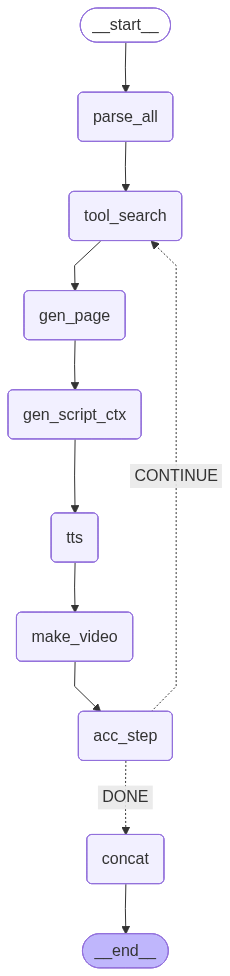

In [130]:
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

builder = StateGraph(State)

builder.add_node("parse_all", node_parse_all)
builder.add_node("gen_page", node_generate_text)
builder.add_node("search", node_search)
builder.add_node("tool_node", ToolNode(tools))
builder.add_node("extract_result", extract_result)
builder.add_node("script_assistant", node_summarize_feedback)
builder.add_node("gen_script_ctx", node_generate_script)
builder.add_node("generate_quiz", node_generate_quiz)
builder.add_node("tts", node_generate_tts)
builder.add_node("generate_video", node_generate_video)
builder.add_node("acc_step", node_accumulate)
builder.add_node("concat", node_concat_video)

builder.set_entry_point("parse_all")

builder.add_edge("parse_all", "gen_page")
builder.add_edge("gen_page", "search")

builder.add_conditional_edges(
    "search",
    need_tools,
    {
        "tool_node": "tool_node",
        END: "extract_result"
    }
)

builder.add_edge("tool_node", "search")

builder.add_edge("extract_result", "script_assistant")
builder.add_edge("script_assistant", "gen_script_ctx")
builder.add_edge("gen_script_ctx", "generate_quiz")
builder.add_edge("generate_quiz", "tts")
builder.add_edge("tts", "generate_video")
builder.add_edge("generate_video", "acc_step")

builder.add_conditional_edges(
    "acc_step",
    should_continue,
    {
        "continue": "gen_page",
        "concat": "concat"
    }
)

builder.add_edge("concat", END)

app = builder.compile()


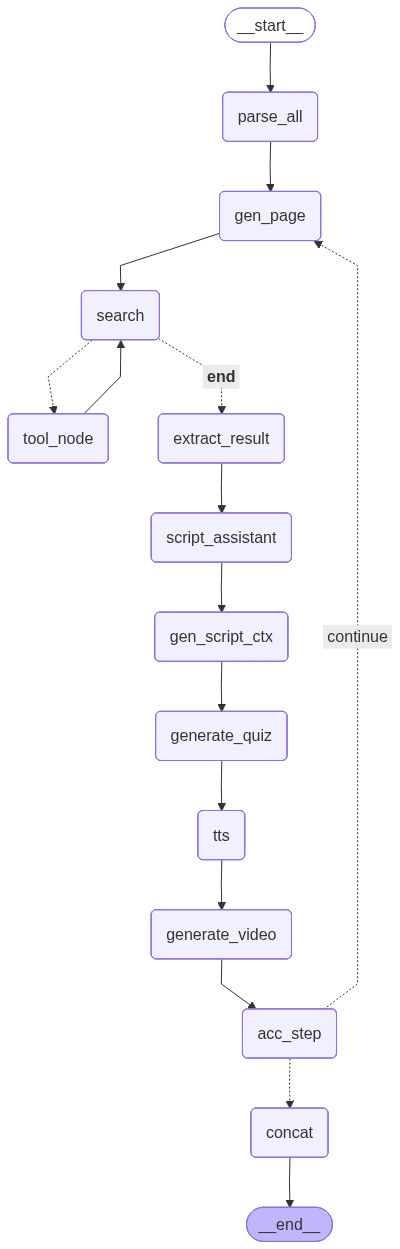

In [92]:
app

## **4. 시스템 실행**

미션3,4에서 수행한 결과를 통합 테스트 해 봅시다.

### (1) 준비 작업
* 파일 업로드
* 사용자 프롬프트 준비

In [124]:
# 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving sample2.pptx to sample2 (1).pptx


In [125]:
# 사용자 프롬프트
USER_PROMPT = {
    "persona": "친절한 AI 강사",
    "voice"  : "nova",
    "tone"   : "친절하고 부드럽게, 명료하게 읽어주세요.",
    "level"  : "비전공자",
    "style"  : "예시와 핵심 요점 중심",
}

# 출력 dir 만들기
WORK_DIR = "./step2_output"
os.makedirs(WORK_DIR, exist_ok=True)

### (2) Agent 실행
* State 초기화
* app 실행
* 동영상 play

In [126]:
# State 초기화
state = {
    "pptx_path"  : pptx_path,
    "work_dir"   : WORK_DIR,
    "prompt"     : USER_PROMPT,
    "slide_index": 0,
}
state

{'pptx_path': 'sample2 (1).pptx',
 'work_dir': './step2_output',
 'prompt': {'persona': '친절한 AI 강사',
  'voice': 'nova',
  'tone': '친절하고 부드럽게, 명료하게 읽어주세요.',
  'level': '비전공자',
  'style': '예시와 핵심 요점 중심'},
 'slide_index': 0}

In [127]:
# app 실행
final_state = app.invoke(state)

전체 슬라이드 파싱을 시작.
-------summurize----
-----------
 [슬라이드별 평균 난이도]
slide_1: 5.00점, slide_2: 5.00점, slide_3: 5.00점

[수강생 피드백]
- 너무 어려워요 설명 쉽게 해주세요
이 강의는 모든 슬라이드에서 평균 난이도가 5.00점으로 매우 어렵다는 피드백이 있습니다. 수강생들은 강의 내용이 이해하기 어렵다고 느끼고 있으므로, 설명을 더 쉽게 풀어주고 접근성을 높이는 것이 필요합니다.
-----generate_tts-----


KeyboardInterrupt: 

In [ ]:
# 로그에 찍힌 경로를 직접 입력합니다.
video_path = "./step2_output/final_lecture.mp4"

with open(video_path, "rb") as f:
    data = f.read()

display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

In [ ]:
quizzes = final_state.get("all_quiz_text", [])

if not quizzes:
    print("⚠️ 생성된 퀴즈가 없습니다. 이전 단계를 확인해 보세요.")
else:
    print(f"✅ 총 {len(quizzes)}개의 퀴즈를 확인했습니다.")
    print("-" * 50)

    for i, quiz in enumerate(quizzes, start=1):
        print(f"\n📝 [문제 {i}] {quiz.get('quiz', '문제 내용 없음')}")

        # 보기 출력
        questions = quiz.get('question', [])
        for j, q in enumerate(questions, start=1):
            print(f"   {j}. {q}")

        print(f"\n   📍 정답: {quiz.get('answer')}번")
        print(f"   💡 해설: {quiz.get('commentary')}")
        print("-" * 50)

✅ 총 6개의 퀴즈를 확인했습니다.
--------------------------------------------------

📝 [문제 1] 모델 모니터링의 주요 목표는 무엇인가요?
   1. 문제를 조기에 탐지하고 근본 원인을 분석하는 것
   2. 모델을 완전히 재구성하는 것
   3. 모델의 성능을 무시하는 것
   4. 데이터를 삭제하는 것

   📍 정답: 1번
   💡 해설: 모델 모니터링의 목표는 문제를 조기에 탐지하고 그 근본 원인을 분석하는 것이지, 모델을 완전히 재구성하거나 데이터를 삭제하는 것이 아닙니다.
--------------------------------------------------

📝 [문제 2] 문제 내용 없음

   📍 정답: None번
   💡 해설: None
--------------------------------------------------

📝 [문제 3] 컨셉 변화란 무엇을 의미하나요?
   1. 시간에 따라 데이터의 변수나 패턴 간의 관계가 지속적으로 변하는 현상이다.
   2. 모델이 예측하는 환경이 변하지 않는 것을 의미한다.
   3. 모델의 성능이 항상 일정하게 유지되는 것을 뜻한다.
   4. 데이터의 양이 줄어드는 현상을 의미한다.

   📍 정답: 1번
   💡 해설: 정답은 '시간에 따라 데이터의 변수나 패턴 간의 관계가 지속적으로 변하는 현상이다.'입니다. 나머지 선택지는 컨셉 변화의 정의와 맞지 않습니다.
--------------------------------------------------

📝 [문제 4] 문제 내용 없음

   📍 정답: None번
   💡 해설: None
--------------------------------------------------

📝 [문제 5] 모델 모니터링 아키텍처에서 배치 모니터링의 특징으로 올바른 것은 무엇인가요?
   1. 정해진 주기나 특정 이벤트 발생 시 데이터를 모니터링한다.
   2. 운영 비용이 상대적으로 높다.
   3. 

## **5. Web APP 개발(Gradio)**
* 화면 개발
    * 입력 : ppt파일, 프롬프트(강의 작성톤), voice 선택(alloy, ...)
    * 출력 : 동영상 play, 동영상 다운로드 버튼
* 기본 화면을 제공합니다. 필요한 기능을 직접 추가하세요.
    * 그래프 컴파일 이름 : `app`
    * state에서 출력 비디오 이름 : `final_video`

In [75]:
import sqlite3

DB_PATH = "./survey_data.db"

# DB 설계
def init_db(db_path=DB_PATH):
    """
    테이블 2개 분리:
    - lectures: PPT 1개 = 1행 = 1차수 (파일명 기준)
    - survey_responses: 설문 응답 1건 = 1행 (한 강의에 여러 명 응답 가능)
    """
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()

    cur.execute("""
        CREATE TABLE IF NOT EXISTS lectures (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            attempt     INTEGER NOT NULL UNIQUE,
            pptx_name   TEXT NOT NULL UNIQUE,
            level       TEXT,
            persona     TEXT,
            summary     TEXT,
            created_at  TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    """)

    cur.execute("""
        CREATE TABLE IF NOT EXISTS survey_responses (
            id              INTEGER PRIMARY KEY AUTOINCREMENT,
            lecture_id      INTEGER NOT NULL,
            slide_1         INTEGER CHECK(slide_1 IS NULL OR (slide_1 BETWEEN 1 AND 5)),
            slide_2         INTEGER CHECK(slide_2 IS NULL OR (slide_2 BETWEEN 1 AND 5)),
            slide_3         INTEGER CHECK(slide_3 IS NULL OR (slide_3 BETWEEN 1 AND 5)),
            slide_4         INTEGER CHECK(slide_4 IS NULL OR (slide_4 BETWEEN 1 AND 5)),
            slide_5         INTEGER CHECK(slide_5 IS NULL OR (slide_5 BETWEEN 1 AND 5)),
            slide_6         INTEGER CHECK(slide_6 IS NULL OR (slide_6 BETWEEN 1 AND 5)),
            slide_7         INTEGER CHECK(slide_7 IS NULL OR (slide_7 BETWEEN 1 AND 5)),
            slide_8         INTEGER CHECK(slide_8 IS NULL OR (slide_8 BETWEEN 1 AND 5)),
            slide_9         INTEGER CHECK(slide_9 IS NULL OR (slide_9 BETWEEN 1 AND 5)),
            slide_10        INTEGER CHECK(slide_10 IS NULL OR (slide_10 BETWEEN 1 AND 5)),
            avg_difficulty  REAL,
            feedback        TEXT,
            created_at      TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            FOREIGN KEY (lecture_id) REFERENCES lectures(id) ON DELETE CASCADE
        )
    """)

    conn.commit()
    conn.close()


def get_or_create_lecture(pptx_name, level, persona, summary, db_path=DB_PATH):
    """
    파일명 기준으로 lecture 조회/생성.
    - 같은 pptx_name이 이미 있으면 그 lecture 리턴 (차수 그대로)
    - 없으면 새 lecture 생성 (차수 자동 +1)
    리턴: (lecture_id, attempt, is_new)
    """
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()

    cur.execute("SELECT id, attempt FROM lectures WHERE pptx_name = ?", (pptx_name,))
    row = cur.fetchone()
    if row:
        conn.close()
        return row[0], row[1], False

    cur.execute("SELECT COALESCE(MAX(attempt), 0) FROM lectures")
    next_attempt = cur.fetchone()[0] + 1

    cur.execute("""
        INSERT INTO lectures (attempt, pptx_name, level, persona, summary)
        VALUES (?, ?, ?, ?, ?)
    """, (next_attempt, pptx_name, level, persona, summary))
    new_id = cur.lastrowid

    conn.commit()
    conn.close()
    return new_id, next_attempt, True


def save_survey_response(lecture_id, slide_difficulties, feedback, db_path=DB_PATH):
    """
    설문 응답 저장.
    - lecture_id: get_or_create_lecture에서 받은 id
    - slide_difficulties: [3, 4, 5, ...] (각 1~5, 길이 1~10)
    """
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()

    padded = list(slide_difficulties) + [None] * (10 - len(slide_difficulties))
    padded = padded[:10]

    valid = [s for s in slide_difficulties if s is not None]
    avg   = sum(valid) / len(valid) if valid else None

    cur.execute("""
        INSERT INTO survey_responses
        (lecture_id,
         slide_1, slide_2, slide_3, slide_4, slide_5,
         slide_6, slide_7, slide_8, slide_9, slide_10,
         avg_difficulty, feedback)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (lecture_id, *padded, avg, feedback))

    new_id = cur.lastrowid
    conn.commit()
    conn.close()
    return new_id


# ── 조회 함수들 ────────────────────────────────────

def get_all_lectures(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()
    cur.execute("SELECT * FROM lectures ORDER BY attempt DESC")
    rows = [dict(r) for r in cur.fetchall()]
    conn.close()
    return rows


def get_responses_by_lecture(lecture_id, db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()
    cur.execute(
        "SELECT * FROM survey_responses WHERE lecture_id = ? ORDER BY id ASC",
        (lecture_id,)
    )
    rows = [dict(r) for r in cur.fetchall()]
    conn.close()
    return rows


def get_slide_avg_difficulty(lecture_id, db_path=DB_PATH):
    """
    특정 강의의 슬라이드별 평균 난이도 (모든 응답자 평균).
    리턴: {'slide_1': 3.5, 'slide_2': 2.0, ...}
    """
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()

    slide_cols = [f"slide_{i}" for i in range(1, 11)]
    select_clause = ", ".join(f"AVG({c})" for c in slide_cols)
    cur.execute(
        f"SELECT {select_clause} FROM survey_responses WHERE lecture_id = ?",
        (lecture_id,)
    )
    row = cur.fetchone()
    conn.close()

    return {
        col: row[i]
        for i, col in enumerate(slide_cols)
        if row[i] is not None
    }


def get_all_feedback(lecture_id, db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    cur  = conn.cursor()
    cur.execute("""
        SELECT id, feedback, created_at
        FROM survey_responses
        WHERE lecture_id = ? AND feedback IS NOT NULL AND feedback != ''
        ORDER BY id ASC
    """, (lecture_id,))
    rows = cur.fetchall()
    conn.close()
    return [{"id": r[0], "feedback": r[1], "created_at": r[2]} for r in rows]


# ── 사용 예시 ───────────────────────────────────────
if __name__ == "__main__":
    init_db()

    # 1. 첫 PPT 업로드 → 1차 강의 생성
    lec_id, attempt, is_new = get_or_create_lecture(
        pptx_name="ml_monitoring_v1.pptx",
        level="비전공자",
        persona="친절한 AI 강사",
        summary="머신러닝 모델 모니터링"
    )
    print(f"강의: id={lec_id}, 차수={attempt}, 새로생성={is_new}")

    # 같은 강의에 여러 사람이 설문 응답
    save_survey_response(lec_id, [3, 4, 5], "3번 슬라이드가 너무 어려워요")
    save_survey_response(lec_id, [2, 3, 4], "전반적으로 무난했음")
    save_survey_response(lec_id, [4, 5, 5], "어렵지만 도움됨")

    # 2. 같은 PPT 업로드 → 같은 강의로 인식 (차수 그대로)
    lec_id2, attempt2, is_new2 = get_or_create_lecture(
        pptx_name="ml_monitoring_v1.pptx",
        level="전공자",
        persona="대학교수",
        summary="머신러닝 모델 모니터링"
    )
    print(f"강의: id={lec_id2}, 차수={attempt2}, 새로생성={is_new2}")

    # 3. 다른 PPT 업로드 → 새 차수
    lec_id3, attempt3, is_new3 = get_or_create_lecture(
        pptx_name="ml_monitoring_v2.pptx",
        level="비전공자",
        persona="친절한 AI 강사",
        summary="머신러닝 모델 모니터링 v2"
    )
    print(f"강의: id={lec_id3}, 차수={attempt3}, 새로생성={is_new3}")

    save_survey_response(lec_id3, [2, 2, 3, 4], "v2가 더 이해하기 쉬웠음")

    # 조회
    print("\n=== 전체 강의 ===")
    for lec in get_all_lectures():
        print(f"[{lec['attempt']}차] {lec['pptx_name']} ({lec['persona']}, {lec['level']})")

    print("\n=== 1차 강의의 슬라이드별 평균 난이도 ===")
    for slide, avg in get_slide_avg_difficulty(1).items():
        print(f"  {slide}: {avg:.2f}")

    print("\n=== 1차 강의의 피드백 모음 ===")
    for fb in get_all_feedback(1):
        print(f"  - {fb['feedback']}")


강의: id=1, 차수=1, 새로생성=False
강의: id=1, 차수=1, 새로생성=False
강의: id=2, 차수=2, 새로생성=False

=== 전체 강의 ===
[2차] ml_monitoring_v2.pptx (친절한 AI 강사, 비전공자)
[1차] ml_monitoring_v1.pptx (친절한 AI 강사, 비전공자)

=== 1차 강의의 슬라이드별 평균 난이도 ===
  slide_1: 3.00
  slide_2: 4.00
  slide_3: 4.67

=== 1차 강의의 피드백 모음 ===
  - 3번 슬라이드가 너무 어려워요
  - 전반적으로 무난했음
  - 어렵지만 도움됨
  - 3번 슬라이드가 너무 어려워요
  - 전반적으로 무난했음
  - 어렵지만 도움됨


In [138]:
import os, time, shutil, threading
import gradio as gr

# ── 전역 로그 큐 및 유틸 ──────────────────────────────────────
_log_lines = []   # [(timestamp, msg), ...]
_log_lock  = threading.Lock()

def log_clear():
    with _log_lock:
        _log_lines.clear()

def log_write(msg: str):
    with _log_lock:
        _log_lines.append((time.time(), msg))

def log_read() -> str:
    with _log_lock:
        sorted_lines = sorted(_log_lines, key=lambda x: x[0])
        return "\n".join(msg for _, msg in sorted_lines)

PERSONA_MAP = {
    "친절한 AI 강사"    : {"voice": "nova",    "tone": "친절하고 부드럽게, 명료하게 읽어주세요."},
    "10년차 현업 전문가" : {"voice": "onyx",    "tone": "자신감 있고 직설적으로, 실용적인 느낌으로 읽어주세요."},
    "대학교수"          : {"voice": "alloy",   "tone": "차분하고 격식 있게, 체계적으로 읽어주세요."},
    "친한 선배"         : {"voice": "shimmer", "tone": "편안하고 캐주얼하게, 친근한 느낌으로 읽어주세요."},
}
LEVELS = ["비전공자", "전공자"]

CUSTOM_CSS = """
body, .gradio-container { background: #faf8f5 !important; font-family: 'Pretendard', sans-serif; }
.step-bar { display: flex; align-items: center; gap: 8px; margin-bottom: 1.75rem; padding-bottom: 1.25rem; border-bottom: 1px solid #e8e0d6; }
.step-item { display: flex; align-items: center; gap: 6px; font-size: 12px; color: #b09e93; }
.step-item.active { color: #8b5e3c; font-weight: 500; }
.step-item.done { color: #c4a882; }
.step-dot { width: 20px; height: 20px; border-radius: 50%; border: 1.5px solid #d9cdc4; display: flex; align-items: center; justify-content: center; font-size: 10px; color: #b09e93; }
.step-item.active .step-dot { background: #8b5e3c; border-color: #8b5e3c; color: #fff; }
.step-item.done  .step-dot { background: #c4a882; border-color: #c4a882; color: #fff; }
.step-line { flex: 1; height: 1px; background: #e8e0d6; }
.preview-box { background: #fdf5ee; border: 1px solid #e8d5bc; border-radius: 8px; padding: 10px 14px; font-size: 13px; color: #7a4f2d; }
.preview-label { font-size: 11px; color: #b09e93; margin-bottom: 4px; text-transform: uppercase; letter-spacing: 0.05em; }
button.primary { background: #8b5e3c !important; border: none !important; color: #fff !important; }
button.primary:hover { background: #7a5032 !important; }
.q-card { background: #fff; border: 1px solid #e8e0d6; border-radius: 10px; padding: 1.25rem; margin-bottom: 12px; }
.q-num  { font-size: 11px; color: #c4a882; font-weight: 500; margin-bottom: 8px; text-transform: uppercase; letter-spacing: 0.05em; }
.q-opt.correct { background: #fdf5ee; border-color: #c4a882; color: #5c3a1e; }
.q-exp  { font-size: 12px; color: #8c7d72; background: #faf6f2; padding: 9px 12px; border-left: 2.5px solid #d9c4b0; }
"""

def step_html(active):
    steps = ["설정", "강의 영상", "퀴즈", "설문"]
    html = '<div class="step-bar">'
    for i, label in enumerate(steps, start=1):
        if i < active:
            cls = "done"
            dot = "✓"
        elif i == active:
            cls = "active"
            dot = str(i)
        else:
            cls = ""
            dot = str(i)
        html += f'<div class="step-item {cls}"><div class="step-dot">{dot}</div><span>{label}</span></div>'
        if i < len(steps):
            html += '<div class="step-line"></div>'
    html += '</div>'
    return html

def loading_html(log_text=""):
    rows = "".join(
        f'<div style="padding:3px 0; border-bottom:1px solid #f0e8e0; font-size:12px; color:#7a5032;">'
        f'<span style="color:#c4a882; margin-right:6px;">▸</span>{line}</div>'
        for line in log_text.strip().split("\n") if line.strip()
    )
    return f"""
    <div style="background:#fdf5ee; border:1px solid #e8d5bc; border-radius:10px;
                padding:20px 24px; margin-top:12px;">
      <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
        <div style="width:14px; height:14px; border-radius:50%;
                    border:2px solid #8b5e3c; border-top-color:transparent;
                    animation:spin 0.8s linear infinite;"></div>
        <span style="font-size:14px; font-weight:500; color:#5c3a1e;">강의 영상 생성 중...</span>
      </div>
      <div style="max-height:180px; overflow-y:auto;">{rows}</div>
    </div>
    <style>@keyframes spin {{to{{transform:rotate(360deg)}}}}</style>
    """

def run_pipeline_ui(pptx_file, persona, level):
    try:
        log_clear()

        # ── 로딩 시작 ──
        yield (
            None, [], {},
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(value=step_html(1)),
            gr.update(visible=True, value=loading_html("준비 중...")),
            gr.update(),
        )

        mapping  = PERSONA_MAP.get(persona, PERSONA_MAP["친절한 AI 강사"])
        work_dir = os.path.join("./webio", f"run-{int(time.time())}")
        os.makedirs(work_dir, exist_ok=True)

        # 원래 파일명 사용
        original_filename = os.path.basename(pptx_file.name)
        pptx_path = os.path.join(work_dir, original_filename)
        shutil.copy(pptx_file.name, pptx_path)

        state = {
            "pptx_path"  : pptx_path,
            "work_dir"   : work_dir,
            "prompt"     : {
                "persona": persona,
                "voice"  : mapping["voice"],
                "tone"   : mapping["tone"],
                "level"  : level,
                "style"  : "예시와 핵심 요점 중심",
            },
            "slide_index": 0,
        }

        result_box = {}
        def _run():
            try:
                result_box["state"] = app.invoke(state) # 앱 로직 연동
            except Exception as e:
                result_box["error"] = e

        t = threading.Thread(target=_run, daemon=True)
        t.start()

        # ── 로딩 폴링 ──
        while t.is_alive():
            time.sleep(1.5)
            yield (
                None, [], {},
                gr.update(visible=False),
                gr.update(visible=False),
                gr.update(visible=False),
                gr.update(visible=False),
                gr.update(value=step_html(1)),
                gr.update(visible=True, value=loading_html(log_read())),
                gr.update(),
            )
        t.join()

        if "error" in result_box:
            raise result_box["error"]

        final_state = result_box["state"]
        video_path  = final_state.get("final_video")
        raw_quiz    = [q for q in final_state.get("all_quiz_text", []) if q and q.get("quiz")][:3]
        quiz_data   = [(q.get("quiz",""), q.get("question",[]), q.get("answer",1), q.get("commentary", q.get("Commentary",""))) for q in raw_quiz]

        # 🌟 설문조사 DB 저장을 위한 메타 데이터 셋팅
        final_state["n_slides"] = final_state.get("n_slides", len(raw_quiz) if raw_quiz else 3)
        final_state["pptx_name"] = os.path.basename(pptx_file.name)
        final_state["level"] = level
        final_state["persona"] = persona
        final_state["summary"] = final_state.get("summary", "자동 생성 강의")

        # ── 성공 ──
        yield (
            video_path,
            quiz_data,
            final_state,
            gr.update(visible=False),
            gr.update(visible=True),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(value=step_html(2)),
            gr.update(visible=False),
            gr.update(value=video_path),
        )

    except Exception as e:
        import traceback
        print(traceback.format_exc())
        # ── 실패 ──
        yield (
            None, [], {},
            gr.update(visible=True),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(value=step_html(1)),
            gr.update(visible=False),
            gr.update(),
        )

def update_preview(persona):
    m = PERSONA_MAP.get(persona, PERSONA_MAP["친절한 AI 강사"])
    return f"""
    <div class="preview-box">
        <div class="preview-label">자동 설정</div>
        {m['voice']} 목소리 &nbsp;·&nbsp; {m['tone']}
    </div>"""

# ── 퀴즈 이벤트 함수 ───────────────────────────────────
def get_safe_index(ans_idx, max_len):
    try:
        idx = int(ans_idx) - 1
        return max(0, min(max_len - 1, idx))
    except:
        return 0

def go_to_quiz(quiz_data):
    if not quiz_data:
        yield (
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=True),
            gr.update(visible=False),
            [],
            gr.update(value="<p style='color:#b09e93;'>퀴즈 데이터가 없습니다.</p>"),
            gr.update(choices=[], value=None, visible=False, interactive=True),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
        )
        return

    q_text, choices, _, _ = quiz_data[0]
    total    = len(quiz_data)
    progress = f"<p style='font-size:12px;color:#b09e93;margin-bottom:6px;'>1 / {total}</p>"
    question = f"<p style='font-size:15px;font-weight:500;color:#2c2420;margin-bottom:4px;'>{q_text}</p>"

    yield (
        gr.update(visible=False), gr.update(visible=False), gr.update(visible=True), gr.update(visible=False),
        [], gr.update(), gr.update(), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False),
    )

    yield (
        gr.update(visible=False), gr.update(visible=False), gr.update(visible=True), gr.update(visible=False),
        [],
        gr.update(value=progress + question),
        gr.update(choices=choices, value=None, label="", interactive=True, visible=True),
        gr.update(visible=False), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False),
    )

def check_answer(quiz_data, answers, user_ans):
    if len(answers) >= len(quiz_data):
        return gr.update(), gr.update(), gr.update(), answers
    if not user_ans:
        return gr.update(), gr.update(visible=True), gr.update(), answers

    idx = len(answers)
    _, choices, ans_idx, commentary = quiz_data[idx]

    correct_idx = get_safe_index(ans_idx, len(choices))
    is_correct = (user_ans == choices[correct_idx])

    mark  = "✅ 정답이에요!" if is_correct else f"❌ 오답이에요. 정답은 '{choices[correct_idx]}'"
    color = "#5c8a3c" if is_correct else "#c0392b"
    exp_html = (
        f"<div style='padding:10px 14px;border-radius:8px;"
        f"border-left:3px solid {'#c4a882' if is_correct else '#e08080'};"
        f"background:#faf6f2;margin-top:8px;'>"
        f"<div style='font-size:13px;font-weight:500;color:{color};margin-bottom:6px;'>{mark}</div>"
        f"<div style='font-size:12px;color:#8c7d72;'>💡 {commentary}</div>"
        f"</div>"
    )
    total      = len(quiz_data)
    next_label = "다음 문제 →" if idx < total - 1 else "결과 보기"
    return (
        gr.update(value=exp_html, visible=True),
        gr.update(visible=True, value=next_label),
        gr.update(interactive=False),
        answers + [user_ans],
    )

def next_question(quiz_data, answers):
    next_idx = len(answers)
    total    = len(quiz_data)
    if next_idx < total:
        q_text, choices, _, _ = quiz_data[next_idx]
        progress = f"<p style='font-size:12px;color:#b09e93;margin-bottom:6px;'>{next_idx+1} / {total}</p>"
        question = f"<p style='font-size:15px;font-weight:500;color:#2c2420;margin-bottom:4px;'>{q_text}</p>"
        return (
            gr.update(value=progress + question),
            gr.update(choices=choices, value=None, label="", interactive=True, visible=True),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False)
        )
    else:
        correct = sum(
            1 for i, (_, choices, ans_idx, _) in enumerate(quiz_data)
            if i < len(answers) and answers[i] == choices[get_safe_index(ans_idx, len(choices))]
        )
        emoji = "🎉" if correct == total else "👍" if correct >= total / 2 else "📚"
        msg   = "완벽해요!" if correct == total else "잘 했어요!" if correct >= total / 2 else "다시 한번 강의를 들어보세요"
        result = (
            f"<div style='text-align:center;padding:24px;background:#fdf5ee;"
            f"border:1px solid #e8d5bc;border-radius:12px;'>"
            f"<div style='font-size:36px;margin-bottom:8px;'>{emoji}</div>"
            f"<div style='font-size:22px;font-weight:600;color:#5c3a1e;'>{correct} / {total} 정답</div>"
            f"<div style='font-size:13px;color:#8c7d72;margin-top:6px;'>{msg}</div>"
            f"</div>"
        )
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=True, value=result),
            gr.update(visible=True)
        )

# ── 설문조사 기능 함수 ─────────────────────────────────────
def prepare_survey(final_state):
    n_slides = final_state.get("n_slides", 0)

    updates = []
    for i in range(10):
        if i < n_slides:
            updates.append(gr.update(visible=True, label=f"{i+1}번 슬라이드의 난이도는 어땠나요?", value=None))
        else:
            updates.append(gr.update(visible=False, value=None))

    return [
        gr.update(visible=False),
        gr.update(visible=True),
        gr.update(value=step_html(4)),
        gr.update(visible=True)
    ] + updates

def submit_survey(final_state, feedback, *survey_radios):
    # 상단에 선언된 실제 DB 연동 함수 호출
    lec_id, _, _ = get_or_create_lecture(
        pptx_name=final_state.get("pptx_name", "unknown_pptx"),
        level=final_state.get("level", "비전공자"),
        persona=final_state.get("persona", "기본 강사"),
        summary=final_state.get("summary", "")
    )

    n_slides = final_state.get("n_slides", 0)

    slide_difficulties = []
    for i in range(n_slides):
        val = survey_radios[i]
        if val:
            slide_difficulties.append(int(val[0]))
        else:
            slide_difficulties.append(None)

    save_survey_response(lec_id, slide_difficulties, feedback)

    success_msg = (
        "<div style='text-align:center; padding: 40px; background:#fdf5ee; border:1px solid #e8d5bc; border-radius:12px; margin-top:20px;'>"
        "<div style='font-size:30px; margin-bottom:10px;'>📝</div>"
        "<h3 style='color:#5c3a1e; margin-bottom:5px;'>설문조사가 성공적으로 제출되었습니다.</h3>"
        "<p style='color:#8c7d72; font-size:14px;'>소중한 의견 감사합니다!</p>"
        "</div>"
    )
    return gr.update(value=success_msg, visible=True), gr.update(visible=False)


def back_to_home():
    return (
        gr.update(visible=True),
        gr.update(visible=False),
        gr.update(visible=False),
        gr.update(visible=False),
    )


# ── Gradio UI 구성 ──────────────────────────────────────────
with gr.Blocks(title="AI 강사", css=CUSTOM_CSS) as demo:

    quiz_state    = gr.State([])
    answers_state = gr.State([])
    final_state   = gr.State({})

    with gr.Column(visible=True) as screen_setup:
        gr.HTML("""
            <div style="border-bottom:1px solid #e8e0d6; padding-bottom:1.25rem; margin-bottom:1.75rem;">
                <h1 style="font-size:20px; font-weight:500; color:#2c2420;">AI 강사</h1>
                <p style="font-size:13px; color:#8c7d72; margin-top:5px;">PPT 파일 하나로 강의 영상과 퀴즈를 자동으로 만들어드립니다.</p>
            </div>
        """)
        step_display = gr.HTML(value=step_html(1))

        inp_ppt     = gr.File(label="PPT 파일", file_types=[".pptx"])
        inp_persona = gr.Radio(choices=list(PERSONA_MAP.keys()), value="친절한 AI 강사", label="강사 페르소나")
        inp_level   = gr.Radio(choices=LEVELS, value="비전공자", label="청중 수준")
        preview_box = gr.HTML(value=update_preview("친절한 AI 강사"))
        run_btn     = gr.Button("강의 영상 생성", variant="primary", elem_classes=["primary"])

    loading_area = gr.HTML(visible=False)

    with gr.Column(visible=False) as screen_video:
        gr.HTML("""
            <div style="border-bottom:1px solid #e8e0d6; padding-bottom:1.25rem; margin-bottom:1.75rem;">
                <h1 style="font-size:20px; font-weight:500; color:#2c2420;">강의 영상</h1>
                <p style="font-size:13px; color:#8c7d72; margin-top:5px;">생성된 강의 영상을 확인하세요.</p>
            </div>
        """)
        gr.HTML(step_html(2))

        out_video    = gr.Video(label="강의 영상", interactive=False)
        out_download = gr.DownloadButton("다운로드", value=None)
        with gr.Row():
            btn_to_quiz = gr.Button("퀴즈 풀기", variant="primary", elem_classes=["primary"])
            btn_back1   = gr.Button("처음으로")

    with gr.Column(visible=False) as screen_quiz:
        gr.HTML("""
            <div style="border-bottom:1px solid #e8e0d6; padding-bottom:1.25rem; margin-bottom:1.75rem;">
                <h1 style="font-size:20px; font-weight:500; color:#2c2420;">퀴즈</h1>
                <p style="font-size:13px; color:#8c7d72; margin-top:5px;">강의 내용을 바탕으로 출제된 문제입니다.</p>
            </div>
        """)
        gr.HTML(step_html(3))

        q_display   = gr.HTML()
        q_radio     = gr.Radio(choices=[], label="", interactive=True)
        exp_display = gr.HTML(visible=False)

        with gr.Row():
            confirm_btn = gr.Button("확인", variant="primary", elem_classes=["primary"])
            next_btn    = gr.Button("다음 문제 →", visible=False)

        result_display = gr.HTML(visible=False)

        with gr.Row():
            btn_go_survey = gr.Button("설문조사 진행하기", visible=False, variant="primary")
            btn_home_quiz = gr.Button("처음으로")

    with gr.Column(visible=False) as screen_survey:
        gr.HTML("""
            <div style="border-bottom:1px solid #e8e0d6; padding-bottom:1.25rem; margin-bottom:1.75rem;">
                <h1 style="font-size:20px; font-weight:500; color:#2c2420;">설문조사</h1>
                <p style="font-size:13px; color:#8c7d72; margin-top:5px;">강의 퀄리티 개선을 위해 소중한 의견을 남겨주세요.</p>
            </div>
        """)
        survey_step_display = gr.HTML()

        survey_radios = []
        survey_choices = ["1 (매우 쉬움)", "2 (쉬움)", "3 (보통)", "4 (어려움)", "5 (매우 어려움)"]

        with gr.Column(visible=True) as survey_form_group:
            for i in range(10):
                r = gr.Radio(choices=survey_choices, visible=False)
                survey_radios.append(r)

            feedback_input = gr.Textbox(label="추가적인 건의사항을 작성해주세요.", lines=4, placeholder="자유롭게 작성해주세요.")
            btn_submit_survey = gr.Button("제출하기", variant="primary", elem_classes=["primary"])

        survey_result_msg = gr.HTML(visible=False)
        with gr.Row():
            btn_home_survey = gr.Button("처음으로")


    # ── 이벤트 바인딩 ────────────────────────────────────
    inp_persona.change(update_preview, inputs=inp_persona, outputs=preview_box)

    run_btn.click(
        run_pipeline_ui,
        inputs=[inp_ppt, inp_persona, inp_level],
        outputs=[
            out_video, quiz_state, final_state,
            screen_setup, screen_video, screen_quiz, screen_survey,
            step_display, loading_area, out_download
        ]
    )

    btn_to_quiz.click(
        go_to_quiz,
        inputs=[quiz_state],
        outputs=[
            screen_setup, screen_video, screen_quiz, screen_survey,
            answers_state,
            q_display, q_radio, exp_display, next_btn, result_display,
            btn_go_survey
        ]
    )

    confirm_btn.click(
        check_answer,
        inputs=[quiz_state, answers_state, q_radio],
        outputs=[exp_display, next_btn, q_radio, answers_state]
    )

    next_btn.click(
        next_question,
        inputs=[quiz_state, answers_state],
        outputs=[q_display, q_radio, exp_display, next_btn, result_display, btn_go_survey]
    )

    btn_go_survey.click(
        prepare_survey,
        inputs=[final_state],
        outputs=[screen_quiz, screen_survey, survey_step_display, survey_form_group] + survey_radios
    )

    btn_submit_survey.click(
        submit_survey,
        inputs=[final_state, feedback_input] + survey_radios,
        outputs=[survey_result_msg, survey_form_group]
    )

    btn_back1.click(back_to_home, outputs=[screen_setup, screen_video, screen_quiz, screen_survey])
    btn_home_quiz.click(back_to_home, outputs=[screen_setup, screen_video, screen_quiz, screen_survey])
    btn_home_survey.click(back_to_home, outputs=[screen_setup, screen_video, screen_quiz, screen_survey])

# ── DB 초기화 및 실행 ────────────────────────────────────
init_db()  # DB와 테이블이 없으면 생성
demo.launch(debug=True)


/tmp/ipykernel_10191/150078168.py:375: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(title="AI 강사", css=CUSTOM_CSS) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f6ab948fe827d90cf8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

전체 슬라이드 파싱을 시작.
-------summurize----
-----------
 [슬라이드별 평균 난이도]
slide_1: 3.67점, slide_2: 3.67점, slide_3: 3.67점

[수강생 피드백]
- 너무 어려워요 설명 쉽게 해주세요
- 너무 쉬우니까 다음에는 더 어려운 내용으로 해주세요
- 모니터링 배치에 대한 개념이 어려웠습니다.
summary
 이 강의는 슬라이드별 평균 난이도가 3.67점으로 중간 정도의 어려움을 보이며, 수강생들은 설명이 어렵다고 느끼거나 더 어려운 내용을 원하고 있습니다. 특히, 모니터링 배치 개념에 대한 이해가 어려웠다는 피드백이 있어, 다음 강의에서는 개념을 더 쉽게 설명하고 다양한 난이도의 내용을 포함하는 것이 필요합니다.
-----generate_tts-----
생성된 오디오 길이: 78.41초
-----generate_video-----
영상 생성 완료: ./webio/run-1777355659/slide0_lecture.mp4
-----accumulate-----
-----should_continue----- (1/3)
-------summurize----
-----------
 [슬라이드별 평균 난이도]
slide_1: 3.67점, slide_2: 3.67점, slide_3: 3.67점

[수강생 피드백]
- 너무 어려워요 설명 쉽게 해주세요
- 너무 쉬우니까 다음에는 더 어려운 내용으로 해주세요
- 모니터링 배치에 대한 개념이 어려웠습니다.
summary
 이 강의는 슬라이드별 평균 난이도가 3.67점으로 중간 정도의 어려움을 보이고 있으며, 수강생들은 내용의 난이도에 대해 상반된 피드백을 주었습니다. 일부는 설명이 어렵다고 느꼈고, 다른 일부는 더 어려운 내용을 원했습니다. 특히 모니터링 배치에 대한 개념이 어려웠다는 의견이 있었습니다.
-----generate_tts-----
생성된 오디오 길이: 61.92초
-----generate_video-----
영상 생성 완료: ./webio/run-

In [137]:
import sqlite3
import pandas as pd

# DB 연결 테스트
conn = sqlite3.connect("survey_data.db")

query = """
SELECT
    L.attempt AS '차수',
    L.pptx_name AS '파일명',
    L.persona AS '페르소나',
    S.avg_difficulty AS '평균 난이도',
    S.slide_1, S.slide_2, S.slide_3, S.slide_4, S.slide_5,
    S.feedback AS '건의사항',
    S.created_at AS '제출일시'
FROM survey_responses S
JOIN lectures L ON S.lecture_id = L.id
ORDER BY S.created_at DESC
"""

df = pd.read_sql_query(query, conn)

conn.close()

df

,차수,파일명,페르소나,평균 난이도,slide_1,slide_2,slide_3,slide_4,slide_5,건의사항,제출일시
0,3,sample2.pptx,10년차 현업 전문가,5.000000,5,5,5,NaN,None,모니터링 배치에 대한 개념이 어려웠습니다.,2026-04-28 05:26:41
1,3,sample2.pptx,10년차 현업 전문가,1.000000,1,1,1,NaN,None,너무 쉬우니까 다음에는 더 어려운 내용으로 해주세요,2026-04-28 05:21:19
2,3,sample2.pptx,10년차 현업 전문가,5.000000,5,5,5,NaN,None,너무 어려워요 설명 쉽게 해주세요,2026-04-28 04:31:24
3,1,ml_monitoring_v1.pptx,친절한 AI 강사,4.000000,3,4,5,NaN,None,3번 슬라이드가 너무 어려워요,2026-04-28 04:17:33
4,1,ml_monitoring_v1.pptx,친절한 AI 강사,3.000000,2,3,4,NaN,None,전반적으로 무난했음,2026-04-28 04:17:33
5,1,ml_monitoring_v1.pptx,친절한 AI 강사,4.666667,4,5,5,NaN,None,어렵지만 도움됨,2026-04-28 04:17:33
6,2,ml_monitoring_v2.pptx,친절한 AI 강사,2.750000,2,2,3,4.0,None,v2가 더 이해하기 쉬웠음,2026-04-28 04:17:33
7,1,ml_monitoring_v1.pptx,친절한 AI 강사,4.000000,3,4,5,NaN,None,3번 슬라이드가 너무 어려워요,2026-04-28 02:37:49
8,1,ml_monitoring_v1.pptx,친절한 AI 강사,3.000000,2,3,4,NaN,None,전반적으로 무난했음,2026-04-28 02:37:49
9,1,ml_monitoring_v1.pptx,친절한 AI 강사,4.666667,4,5,5,NaN,None,어렵지만 도움됨,2026-04-28 02:37:49
